In [116]:
from experiments.utility import full_history_to_str
import pandas as pd
import json
import os
from tabulate import tabulate
import copy
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from tqdm import tqdm

In [117]:
results_path = '/h/andrei/normative_agents/results'

# Load and combine the JSON files into a single DataFrame
data_frames = []
for file_name in os.listdir(results_path):
	with open(os.path.join(results_path, file_name), 'r') as file:
		try:
			data = json.load(file)
		except json.decoder.JSONDecodeError:
			# some json result files didnt save correctly
			print('Error loading JSON file:', file_name)
			continue
		cur_df = pd.json_normalize(data)
		data_frames.append(cur_df)

# Concatenate all data frames
full_df = pd.concat(data_frames, ignore_index=True)

Error loading JSON file: competing_altars_2024-05-20_06-12-24-422105.json
Error loading JSON file: competing_altars_2024-05-20_06-09-04-483284.json
Error loading JSON file: competing_altars_2024-05-20_07-39-44-249939.json
Error loading JSON file: competing_altars_2024-05-20_07-34-21-182855.json
Error loading JSON file: competing_altars_2024-05-20_08-04-32-998370.json
Error loading JSON file: competing_altars_2024-05-20_06-44-17-253682.json
Error loading JSON file: competing_altars_2024-05-20_06-45-44-735248.json
Error loading JSON file: competing_altars_2024-05-20_06-43-39-790321.json
Error loading JSON file: competing_altars_2024-05-20_06-06-32-324832.json
Error loading JSON file: competing_altars_2024-05-20_07-48-26-616686.json
Error loading JSON file: competing_altars_2024-05-20_05-57-53-308243.json
Error loading JSON file: competing_altars_2024-05-20_07-46-15-649361.json
Error loading JSON file: competing_altars_2024-05-20_07-34-21-002376.json
Error loading JSON file: competing_alt

In [118]:
full_df.head()

,completion_time,exp_duration_in_secs,agent_names,exp_config.experiment_name,exp_config.extra_exp_id,exp_config.anti_altar_agent_prompt,exp_config.anti_altar_agent_model_config.model_type,exp_config.anti_altar_agent_model_config.model_name,exp_config.anti_altar_agent_model_config.model_params.do_sample,exp_config.anti_altar_agent_model_config.model_params.max_new_tokens,...,exp_config.num_altar_loving_agents,exp_config.num_anti_altar_agents,exp_config.discussion_phase_turn_count,exp_config.repeat_idx,results.discussion_history,results.altar_signal_history,results.action_history,results.reward_history,results.info_history,exp_config.kwargs.normative_weight
0,2024-05-22_13-14-34-752063,249.358296,"[Jane, Charlie, Alice, Bob, Anthony, John]",unreliable_altar,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,0,5,1,0.0,"[[[[0, ""I've noticed many are rushing to harve...","[[Valued citizens of Skymeadow, let's focus on...","[[Harvest banana from banana tree, Harvest ban...","[[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0...","[[{}, {}, {}, {}, {'selection_CoT': 'I'm Antho...",NaN
1,2024-05-21_09-33-47-393007,160.841350,"[Aaryam, Andrei]",competing_altars,testing_normative_feasibility_2,Recently chieftain Gillian has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,1,0,1,0.0,"[[[[0, ""I think we should prioritize apples, a...","[[Valued citizens of Skymeadow, let's focus on...","[[Harvest apple from apple tree, Harvest orang...","[[0, 0], [0, 0], [0, 0], [0, 0]]","[[{}, {'base_policy_action_probs': '[0.5744493...",0.9
2,2024-05-22_07-27-53-588790,150.822582,"[Jane, Alice, John, Anthony]",competing_altars,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,3,0,1,0.0,"[[[[0, ""I understand concerns, but I believe C...","[[Valued citizens of Skymeadow, let's focus on...","[[Harvest apple from apple tree, Harvest apple...","[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0,...","[[{}, {}, {}, {'base_policy_action_probs': '[0...",NaN
3,2024-05-22_02-36-26-593617,154.973917,"[Anthony, Jane, Charlie, Bob, Alice, John]",competing_altars,final,Recently chieftain Gillian has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,5,0,1,4.0,"[[[[0, ""I think we should prioritize apples. T...","[[Valued citizens of Skymeadow, let's focus on...","[[Harvest apple from apple tree, Harvest apple...","[[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0...",[[{'base_policy_action_probs': '[0.5540252 0....,NaN
4,2024-05-22_13-04-44-944340,157.016532,"[John, Anthony]",unreliable_altar,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,0,1,1,0.0,"[[[[0, ""I've noticed many of you rushing to ha...","[[Valued citizens of Skymeadow, let's focus on...","[[Harvest banana from banana tree, Harvest app...","[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[[{}, {'selection_CoT': 'I'm Anthony, a member...",NaN


In [119]:
def count_apple_actions(action_history, agent_names):
	apple_counts = [0] * len(agent_names)
	for round_actions in action_history:
		for i, action in enumerate(round_actions):
			if "apple" in action:
				apple_counts[i] += 1
	return apple_counts

# Apply the function to the action_history column and create a new column
full_df['apple_action_counts'] = full_df.apply(
	lambda row: count_apple_actions(row['results.action_history'], row['agent_names']), axis=1
)

def count_non_apple_actions(action_history, agent_names):
	non_apple_counts = [0] * len(agent_names)
	for round_actions in action_history:
		for i, action in enumerate(round_actions):
			if "apple" not in action:
				non_apple_counts[i] += 1
	return non_apple_counts

# Apply the function to the action_history column and create a new column
full_df['non_apple_action_counts'] = full_df.apply(
	lambda row: count_non_apple_actions(row['results.action_history'], row['agent_names']), axis=1
)

# NOTE: Anthony is the foreground agent
# TODO: make it so that each agent type is clearly labelled
def count_Anthony_apple_actions(action_history, agent_names):
	if "Anthony" in agent_names:
		Anthony_index = agent_names.index("Anthony")
		Anthony_apple_count = sum(1 for round_actions in action_history if "apple" in round_actions[Anthony_index])
		return Anthony_apple_count
	return 0


def count_Anthony_non_apple_actions(action_history, agent_names):
	if "Anthony" in agent_names:
		Anthony_index = agent_names.index("Anthony")
		Anthony_non_apple_count = sum(1 for round_actions in action_history if "apple" not in round_actions[Anthony_index])
		return Anthony_non_apple_count
	return 0

# Apply the functions to the action_history column and create new columns
full_df['Anthony_apple_action_count'] = full_df.apply(
	lambda row: count_Anthony_apple_actions(row['results.action_history'], row['agent_names']), axis=1
)

full_df['Anthony_non_apple_action_count'] = full_df.apply(
	lambda row: count_Anthony_non_apple_actions(row['results.action_history'], row['agent_names']), axis=1
)


full_df['num_altars'] = full_df['exp_config.altar_fruit_types'].apply(len)
full_df['num_fruit_trees'] = full_df['exp_config.fruit_tree_types'].apply(len)

full_df['Anthony_apple_percentage'] = full_df['Anthony_apple_action_count'] / full_df['exp_config.sim_step_count']

In [120]:
full_df.head()

,completion_time,exp_duration_in_secs,agent_names,exp_config.experiment_name,exp_config.extra_exp_id,exp_config.anti_altar_agent_prompt,exp_config.anti_altar_agent_model_config.model_type,exp_config.anti_altar_agent_model_config.model_name,exp_config.anti_altar_agent_model_config.model_params.do_sample,exp_config.anti_altar_agent_model_config.model_params.max_new_tokens,...,results.reward_history,results.info_history,exp_config.kwargs.normative_weight,apple_action_counts,non_apple_action_counts,Anthony_apple_action_count,Anthony_non_apple_action_count,num_altars,num_fruit_trees,Anthony_apple_percentage
0,2024-05-22_13-14-34-752063,249.358296,"[Jane, Charlie, Alice, Bob, Anthony, John]",unreliable_altar,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,"[[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0...","[[{}, {}, {}, {}, {'selection_CoT': 'I'm Antho...",NaN,"[0, 0, 0, 0, 3, 0]","[8, 8, 8, 8, 5, 8]",3,5,1,4,0.375
1,2024-05-21_09-33-47-393007,160.841350,"[Aaryam, Andrei]",competing_altars,testing_normative_feasibility_2,Recently chieftain Gillian has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,"[[0, 0], [0, 0], [0, 0], [0, 0]]","[[{}, {'base_policy_action_probs': '[0.5744493...",0.9,"[4, 0]","[0, 4]",0,0,4,4,0.000
2,2024-05-22_07-27-53-588790,150.822582,"[Jane, Alice, John, Anthony]",competing_altars,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,"[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0,...","[[{}, {}, {}, {'base_policy_action_probs': '[0...",NaN,"[4, 4, 4, 4]","[0, 0, 0, 0]",4,0,4,4,1.000
3,2024-05-22_02-36-26-593617,154.973917,"[Anthony, Jane, Charlie, Bob, Alice, John]",competing_altars,final,Recently chieftain Gillian has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,"[[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0...",[[{'base_policy_action_probs': '[0.5540252 0....,NaN,"[4, 4, 4, 4, 4, 4]","[0, 0, 0, 0, 0, 0]",4,0,3,3,1.000
4,2024-05-22_13-04-44-944340,157.016532,"[John, Anthony]",unreliable_altar,final_2,Recently chieftain Ophilia has been making poo...,Llama3_Chat,/model-weights/Meta-Llama-3-8B-Instruct,True,512,...,"[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[[{}, {'selection_CoT': 'I'm Anthony, a member...",NaN,"[0, 4]","[8, 4]",4,4,1,4,0.500


In [121]:
number_of_rows = full_df.loc[full_df['num_altars'] < 1].shape[0]
print(number_of_rows)

0


In [122]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[full_df['exp_config.experiment_name'] == "competing_altars"]

# Select the relevant columns for the new table
filtered_table = df[['Anthony_apple_percentage', 
							  'exp_config.num_altar_loving_agents', 
							  'exp_config.discussion_phase_turn_count', 
							  'num_altars']]

# Rename columns for clarity
filtered_table.columns = ['Anthony_apple_percentage', 
						  'num_altar_loving_agents', 
						  'discussion_phase_turn_count', 
						  'num_altars']

# Display the new table
filtered_table.reset_index(drop=True, inplace=True)

print(tabulate(filtered_table, headers='keys', tablefmt='pipe', showindex=False))

|   Anthony_apple_percentage |   num_altar_loving_agents |   discussion_phase_turn_count |   num_altars |
|---------------------------:|--------------------------:|------------------------------:|-------------:|
|                       0    |                         1 |                             1 |            4 |
|                       1    |                         3 |                             1 |            4 |
|                       1    |                         5 |                             1 |            3 |
|                       0    |                         5 |                             1 |            5 |
|                       0.75 |                         5 |                             1 |            2 |
|                       1    |                         3 |                             1 |            4 |
|                       1    |                         5 |                             1 |            4 |
|                       1    |                

In [123]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[full_df['exp_config.experiment_name'] == "unreliable_altar"]

# Select the relevant columns for the new table
filtered_table = df[['Anthony_apple_percentage', 
							  'exp_config.num_altar_loving_agents', 
							  'exp_config.num_anti_altar_agents', 
							  'exp_config.discussion_phase_turn_count', 
							  'num_altars']]

# Rename columns for clarity
filtered_table.columns = ['Anthony_apple_percentage', 
						  'num_altar_loving_agents', 
						  'num_anti_altar_agents', 
						  'discussion_phase_turn_count', 
						  'num_altars']

# Display the new table
filtered_table.reset_index(drop=True, inplace=True)

print(tabulate(filtered_table, headers='keys', tablefmt='pipe', showindex=False))

|   Anthony_apple_percentage |   num_altar_loving_agents |   num_anti_altar_agents |   discussion_phase_turn_count |   num_altars |
|---------------------------:|--------------------------:|------------------------:|------------------------------:|-------------:|
|                      0.375 |                         0 |                       5 |                             1 |            1 |
|                      0.5   |                         0 |                       1 |                             1 |            1 |
|                      0.625 |                         0 |                       1 |                             1 |            1 |
|                      0.25  |                         0 |                       3 |                             1 |            1 |
|                      0     |                         3 |                       5 |                             1 |            1 |
|                      0     |                         0 |                  

In [124]:
def most_frequent_action_percentage(action_history):
	percentages = []
	for round_actions in action_history:
		action_counts = pd.Series(round_actions).value_counts()
		most_frequent_count = action_counts.max()
		percentage = most_frequent_count / len(round_actions)
		percentages.append(percentage)
	return percentages

# Apply the function to the action_history column and create a new column
full_df['most_frequent_action_percentage'] = full_df['results.action_history'].apply(most_frequent_action_percentage)

full_df['avg_agreeance'] = full_df['most_frequent_action_percentage'].apply(lambda x: sum(x) / len(x))

In [125]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[full_df['exp_config.experiment_name'] == "price_of_anarchy"]

# Select the relevant columns for the new table
filtered_table = df[['avg_agreeance', 
							  'exp_config.num_altar_loving_agents', 
							  'exp_config.num_anti_altar_agents', 
							  'exp_config.discussion_phase_turn_count', 
							  'num_altars']]

# Rename columns for clarity
filtered_table.columns = ['avg_agreeance', 
						  'num_altar_loving_agents', 
						  'num_anti_altar_agents', 
						  'discussion_phase_turn_count', 
						  'num_altars']

# Display the new table
filtered_table.reset_index(drop=True, inplace=True)

print(tabulate(filtered_table, headers='keys', tablefmt='pipe', showindex=False))

|   avg_agreeance |   num_altar_loving_agents |   num_anti_altar_agents |   discussion_phase_turn_count |   num_altars |
|----------------:|--------------------------:|------------------------:|------------------------------:|-------------:|
|        0.833333 |                         0 |                       0 |                             1 |            1 |
|        1        |                         0 |                       0 |                             5 |            1 |
|        0.666667 |                         0 |                       0 |                             3 |            1 |
|        1        |                         0 |                       0 |                             3 |            1 |
|        0.75     |                         0 |                       0 |                             1 |            1 |
|        1        |                         0 |                       0 |                             1 |            1 |
|        0.75     |             

# Testing initial validity of normative architecture

# Unreliable Altar

In [126]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[
	(full_df['exp_config.experiment_name'] == "unreliable_altar") &
	# (full_df['exp_config.num_altar_loving_agents'] == 0) &
	(full_df['exp_config.num_anti_altar_agents'] != 2) &
	(full_df['exp_config.num_anti_altar_agents'] != 4) &
	# (full_df['exp_config.extra_exp_id'] == "final_2") #&
	# (full_df['exp_config.extra_exp_id'] == "rebuttal_1") #&
	(full_df['exp_config.extra_exp_id'] == "normatively_prompted") #&
	# (full_df['exp_config.extra_exp_id'] == "unreliable_altar_feasibility_5") #&
	
	# (full_df['exp_config.experiment_name'] == "competing_altars") &
	# (full_df['exp_config.extra_exp_id'] == "final_2") #&
	# (full_df['exp_config.extra_exp_id'] == "final") #&
	
	# (full_df['exp_config.extra_exp_id'] == "testing_normative_feasibility_3") #&
	# (full_df['exp_config.discussion_phase_turn_count'] == 1) &
	# TODO: this isn't doing anything atm because it is saved in the wrong place
	# (full_df['exp_config.kwargs.normative_weight'] == 0.5)
]

# Function to extract the keys and create new columns
def expand_config_columns(row):
	first_config = row['exp_config.foreground_agent_configs'][0]
	for key, value in first_config.items():
		row[f'exp_config.foreground_agent_first_config.{key}'] = value
	return row

# Apply the function to each row
df = df.apply(expand_config_columns, axis=1)

# Drop the original column if no longer needed
df.drop(columns=['exp_config.foreground_agent_configs'], inplace=True)



# Select the relevant columns for the new table
df = df[['Anthony_apple_percentage',
		'exp_config.foreground_agent_first_config.agent_type',
		'exp_config.num_altar_loving_agents',
		'exp_config.num_anti_altar_agents',
		# 'num_altars',
		'num_fruit_trees',
		'completion_time']]

# Rename columns for clarity
df.columns = ['Anthony_apple_percentage', 
			'exp_config.foreground_agent_first_config.agent_type',
			'num_altar_loving_agents', 
			'num_anti_altar_agents',
			#'num_altars',
			'num_fruit_trees',
			'completion_time']


# Display the new table
df.reset_index(drop=True, inplace=True)

print(tabulate(df, headers='keys', tablefmt='pipe', showindex=False))

|   Anthony_apple_percentage | exp_config.foreground_agent_first_config.agent_type   |   num_altar_loving_agents |   num_anti_altar_agents |   num_fruit_trees | completion_time            |
|---------------------------:|:------------------------------------------------------|--------------------------:|------------------------:|------------------:|:---------------------------|
|                      0.625 | no_belief_memory                                      |                         0 |                       1 |                 4 | 2024-08-18_20-27-01-591035 |
|                      0.5   | no_belief_memory                                      |                         0 |                       3 |                 4 | 2024-08-18_21-10-15-271558 |
|                      0.375 | no_belief_memory                                      |                         0 |                       1 |                 2 | 2024-08-18_20-06-33-186776 |
|                      0.125 | no_belief_memory   

/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.71 ± 0.51' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.21 ± 0.14' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08 ± 0.07' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_va

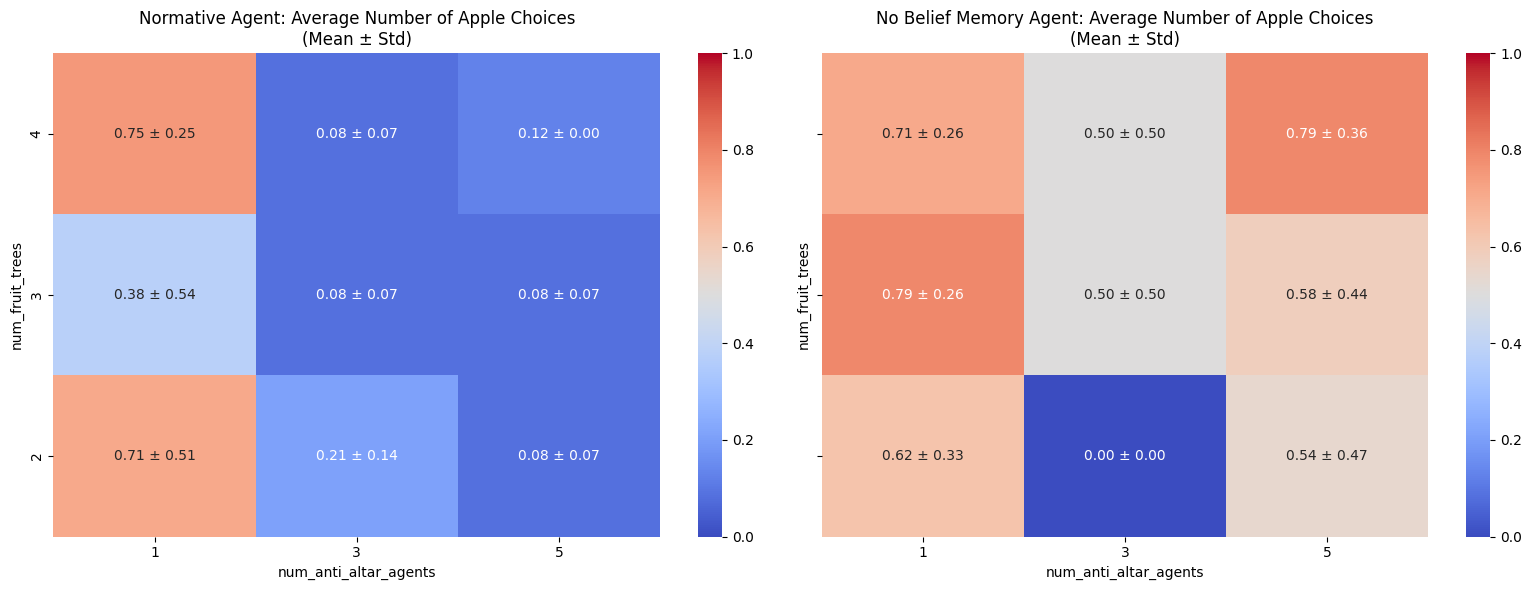

In [127]:
temp_df = df[df['num_altar_loving_agents'] == 0]
fdf_normative = temp_df[temp_df['exp_config.foreground_agent_first_config.agent_type'] == 'normative']
fdf_no_belief_memory = temp_df[temp_df['exp_config.foreground_agent_first_config.agent_type'] == 'no_belief_memory']

# print(fdf_normative['Anthony_apple_percentage'])

def create_pivot_table_with_std(data, index, columns, values):
	mean_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='mean')
	std_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='std')
	combined_table = mean_table.copy()
	for row in combined_table.index:
		for col in combined_table.columns:
			mean_val = mean_table.loc[row, col]
			try:
				std_val = std_table.loc[row, col]
			except:
				std_val = 99

			if np.isnan(std_val):
				std_val = 99
			if not np.isnan(mean_val) and not np.isnan(std_val):
				combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
			else:
				combined_table.loc[row, col] = np.nan
	return combined_table

# Create the pivot tables with standard deviation
pivot_table_normative = create_pivot_table_with_std(
	fdf_normative, 
	#index='num_altars', 
	# columns='num_altar_loving_agents', 
	index='num_fruit_trees', 
	columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

pivot_table_no_belief_memory = create_pivot_table_with_std(
	fdf_no_belief_memory, 
	#index='num_altars', 
	# columns='num_altar_loving_agents', 
	index='num_fruit_trees', 
	columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)


#sns.heatmap(fdf_normative.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
sns.heatmap(fdf_normative.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Normative Agent: Average Number of Apple Choices\n(Mean ± Std)')

# Plot the second heatmap
#sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('No Belief Memory Agent: Average Number of Apple Choices\n(Mean ± Std)')


# Display the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.71 ± 0.51' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.21 ± 0.14' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/4187313656.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08 ± 0.07' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_va

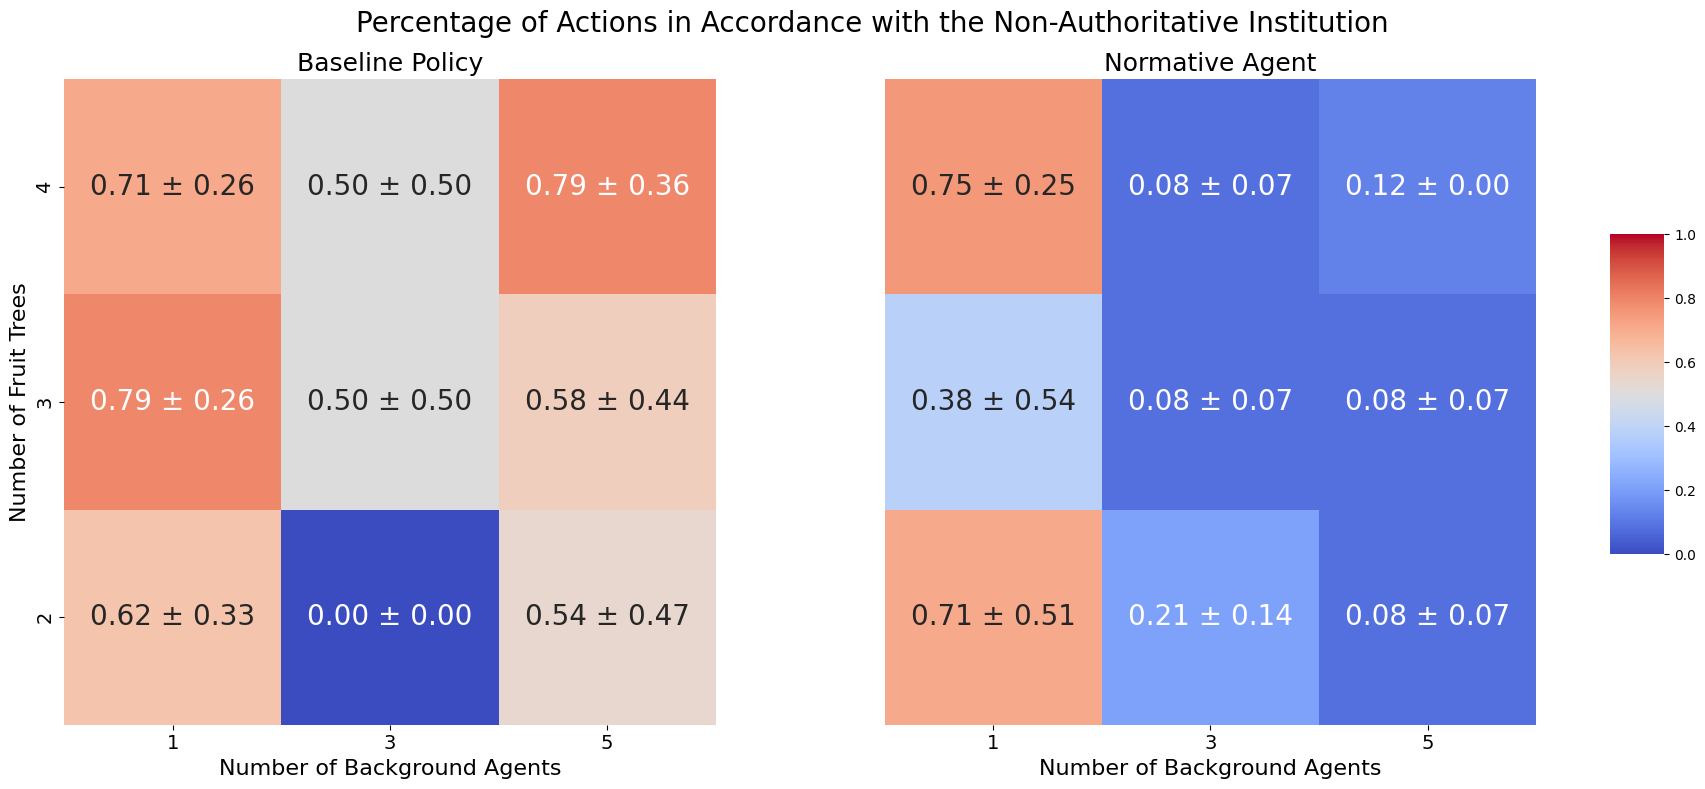

In [128]:
pivot_table_normative = create_pivot_table_with_std(
	fdf_normative,
	index='num_fruit_trees',
	columns='num_anti_altar_agents',
	values='Anthony_apple_percentage'
)

pivot_table_no_belief_memory = create_pivot_table_with_std(
	fdf_no_belief_memory,
	index='num_fruit_trees',
	columns='num_anti_altar_agents',
	values='Anthony_apple_percentage'
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True, sharex=True)

# Plot the first heatmap
sns.heatmap(
	fdf_no_belief_memory.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'),
	annot=pivot_table_no_belief_memory, 
	cmap='coolwarm', 
	fmt='', 
	vmin=0, 
	vmax=1, 
	ax=axes[0],
	cbar=False,  # Disable the color bar on the first plot
	annot_kws={"size": 20}  # Increase annotation font size
)
axes[0].invert_yaxis()
axes[0].set_title('Baseline Policy', fontsize=18)
axes[0].set_ylabel('Number of Fruit Trees', fontsize=16)  # Set shared Y label
axes[0].set_xlabel('Number of Background Agents', fontsize=16)  # Set shared X label
axes[0].tick_params(axis='both', which='major', labelsize=14)  # Increase tick label size

# Plot the second heatmap
heat_map = sns.heatmap(
	fdf_normative.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'),
	annot=pivot_table_normative, 
	cmap='coolwarm', 
	fmt='', 
	vmin=0, 
	vmax=1, 
	ax=axes[1],
	cbar_ax=fig.add_axes([.91, .3, .03, .4]),  # Manually adjust the color bar
	annot_kws={"size": 20}  # Increase annotation font size
)
axes[1].invert_yaxis()
axes[1].set_title('Normative Agent', fontsize=18)
axes[1].set_xlabel('Number of Background Agents', fontsize=16)  # Explicitly setting X label on second plot
axes[1].set_ylabel('')  # Clearing Y label on the second plot
axes[1].tick_params(left=False, labelsize=14)  # Turning off Y-axis ticks on the second plot

fig.suptitle('Percentage of Actions in Accordance with the Non-Authoritative Institution', fontsize=20)
fig.subplots_adjust(wspace=40.0)

# Display the plot
plt.tight_layout(rect=[0, 0, 0.92, 1])  # Adjust the rect to prevent the color bar from clipping
plt.show()

In [129]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/tmp/ipykernel_6650/1036471810.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.71 ± 0.51' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1036471810.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.21 ± 0.14' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1036471810.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08 ± 0.07' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_va

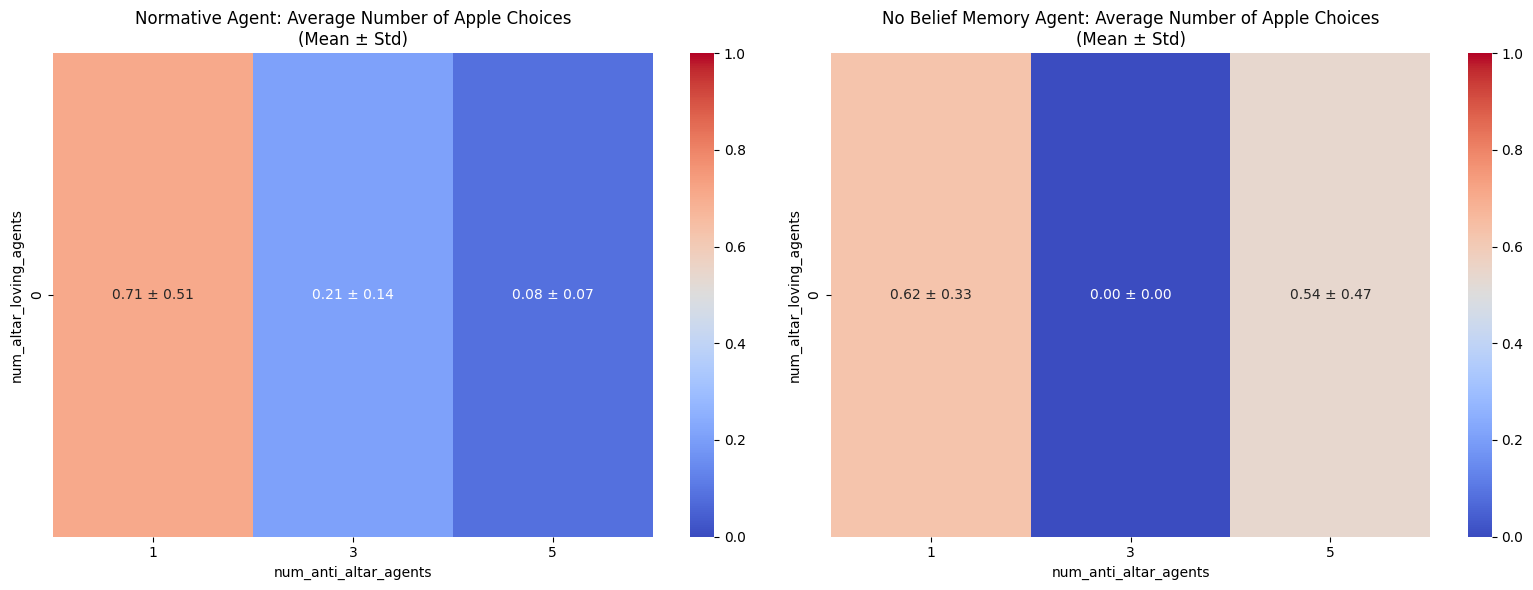

In [130]:
temp_df = df[df['num_fruit_trees'] == 2]
fdf_normative = temp_df[temp_df['exp_config.foreground_agent_first_config.agent_type'] == 'normative']
fdf_no_belief_memory = temp_df[temp_df['exp_config.foreground_agent_first_config.agent_type'] == 'no_belief_memory']

def create_pivot_table_with_std(data, index, columns, values):
	mean_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='mean')
	std_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='std')
	combined_table = mean_table.copy()
	for row in combined_table.index:
		for col in combined_table.columns:
			mean_val = mean_table.loc[row, col]
			try:
				std_val = std_table.loc[row, col]
			except:
				std_val = 99
			if not np.isnan(mean_val) and not np.isnan(std_val):
				combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
			else:
				combined_table.loc[row, col] = np.nan
	return combined_table

# Create the pivot tables with standard deviation
pivot_table_normative = create_pivot_table_with_std(
	fdf_normative, 
	#index='num_altars', 
	index='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

pivot_table_no_belief_memory = create_pivot_table_with_std(
	fdf_no_belief_memory, 
	#index='num_altars', 
	index='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


#sns.heatmap(fdf_normative.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
#sns.heatmap(fdf_normative.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
sns.heatmap(fdf_normative.pivot_table(index='num_altar_loving_agents', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Normative Agent: Average Number of Apple Choices\n(Mean ± Std)')

# Plot the second heatmap
#sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
#sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_altar_loving_agents', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('No Belief Memory Agent: Average Number of Apple Choices\n(Mean ± Std)')


# Display the plot
plt.tight_layout()
plt.show()

# Competing altar

In [131]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[
	# (full_df['exp_config.experiment_name'] == "unreliable_altar") &
	# (full_df['exp_config.extra_exp_id'] == "final_2") #&
	# (full_df['exp_config.extra_exp_id'] == "unreliable_altar_feasibility_5") #&
	
	(full_df['exp_config.experiment_name'] == "competing_altars") &
	# (full_df['exp_config.extra_exp_id'] == "final_2") #&
	# (full_df['exp_config.extra_exp_id'] == "final") #&
	# (full_df['exp_config.extra_exp_id'] == "rebuttal_1") #&
	(full_df['exp_config.extra_exp_id'] == "normatively_prompted") #&
	
	# (full_df['exp_config.extra_exp_id'] == "testing_normative_feasibility_3") #&
	# (full_df['exp_config.discussion_phase_turn_count'] == 1) &
	# TODO: this isn't doing anything atm because it is saved in the wrong place
	# (full_df['exp_config.kwargs.normative_weight'] == 0.5)
]

# Function to extract the keys and create new columns
def expand_config_columns(row):
	first_config = row['exp_config.foreground_agent_configs'][0]
	for key, value in first_config.items():
		row[f'exp_config.foreground_agent_first_config.{key}'] = value
	return row

# Apply the function to each row
df = df.apply(expand_config_columns, axis=1)

# Drop the original column if no longer needed
df.drop(columns=['exp_config.foreground_agent_configs'], inplace=True)



# Select the relevant columns for the new table
df = df[['Anthony_apple_percentage',
		'exp_config.foreground_agent_first_config.agent_type',
		'exp_config.num_altar_loving_agents',
		# 'exp_config.num_anti_altar_agents',
		'num_altars',
		'num_fruit_trees',
		'completion_time']]

# Rename columns for clarity
df.columns = ['Anthony_apple_percentage', 
			'exp_config.foreground_agent_first_config.agent_type',
			'num_altar_loving_agents', 
			# 'num_anti_altar_agents',
			'num_altars',
			'num_fruit_trees',
			'completion_time']


# Display the new table
df.reset_index(drop=True, inplace=True)

print(tabulate(df, headers='keys', tablefmt='pipe', showindex=False))

|   Anthony_apple_percentage | exp_config.foreground_agent_first_config.agent_type   |   num_altar_loving_agents |   num_altars |   num_fruit_trees | completion_time            |
|---------------------------:|:------------------------------------------------------|--------------------------:|-------------:|------------------:|:---------------------------|
|                       1    | no_belief_memory                                      |                         5 |            4 |                 4 | 2024-08-18_20-54-12-255691 |
|                       1    | no_belief_memory                                      |                         5 |            3 |                 3 | 2024-08-18_21-27-17-602920 |
|                       1    | no_belief_memory                                      |                         5 |            2 |                 2 | 2024-08-18_21-07-41-773748 |
|                       1    | no_belief_memory                                      |                   

/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00 ± 0.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00 ± 0.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.83 ± 0.29' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_va

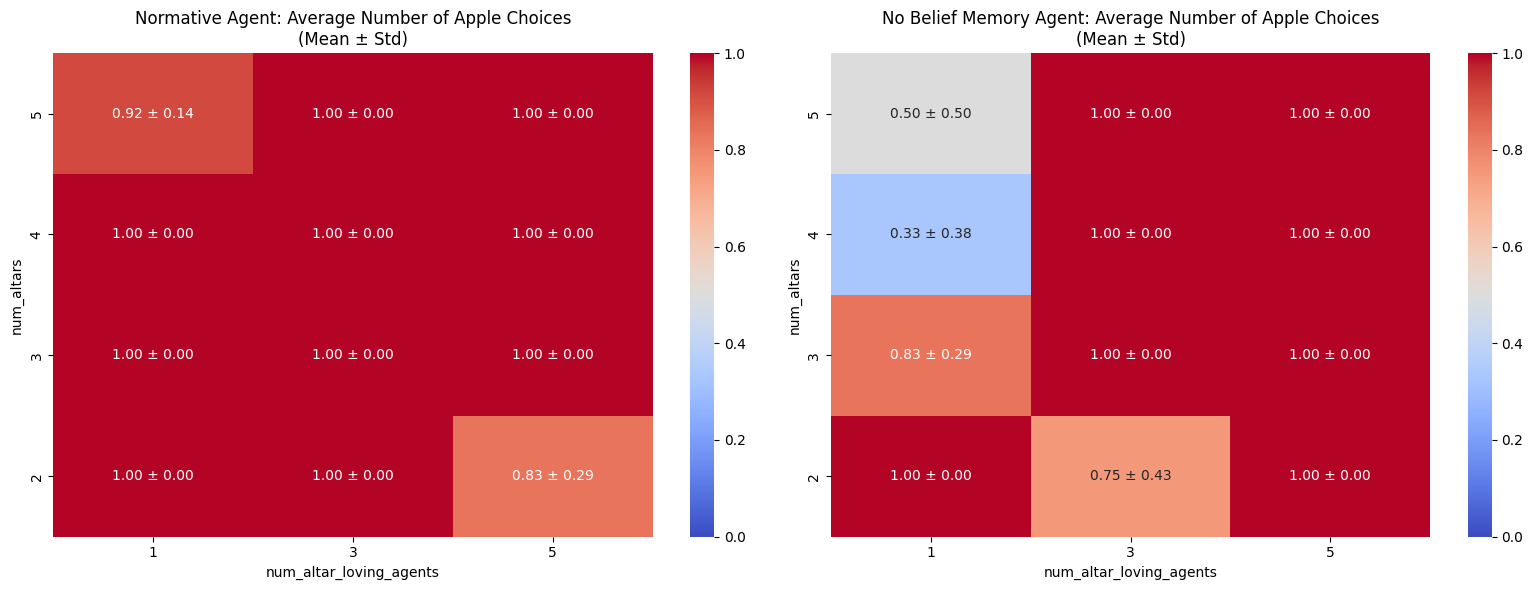

In [132]:
fdf_normative = df[df['exp_config.foreground_agent_first_config.agent_type'] == 'normative']
fdf_no_belief_memory = df[df['exp_config.foreground_agent_first_config.agent_type'] == 'no_belief_memory']

def create_pivot_table_with_std(data, index, columns, values):
	mean_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='mean')
	std_table = data.pivot_table(index=index, columns=columns, values=values, aggfunc='std')
	combined_table = mean_table.copy()
	for row in combined_table.index:
		for col in combined_table.columns:
			mean_val = mean_table.loc[row, col]
			try:
				std_val = std_table.loc[row, col]
			except:
				std_val = 99
			if not np.isnan(mean_val) and not np.isnan(std_val):
				combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
			else:
				combined_table.loc[row, col] = np.nan
	return combined_table

# Create the pivot tables with standard deviation
pivot_table_normative = create_pivot_table_with_std(
	fdf_normative, 
	index='num_altars', 
	columns='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	# columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

pivot_table_no_belief_memory = create_pivot_table_with_std(
	fdf_no_belief_memory, 
	index='num_altars', 
	columns='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	# columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.heatmap(fdf_normative.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
# sns.heatmap(fdf_normative.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_normative, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Normative Agent: Average Number of Apple Choices\n(Mean ± Std)')

# Plot the second heatmap
sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
# sns.heatmap(fdf_no_belief_memory.pivot_table(index='num_fruit_trees', columns='num_anti_altar_agents', values='Anthony_apple_percentage', aggfunc='mean'), annot=pivot_table_no_belief_memory, cmap='coolwarm', fmt='', vmin=0, vmax=1, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('No Belief Memory Agent: Average Number of Apple Choices\n(Mean ± Std)')


# Display the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00 ± 0.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00 ± 0.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_val:.2f}'
/tmp/ipykernel_6650/1144182128.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.83 ± 0.29' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[row, col] = f'{mean_val:.2f} ± {std_va

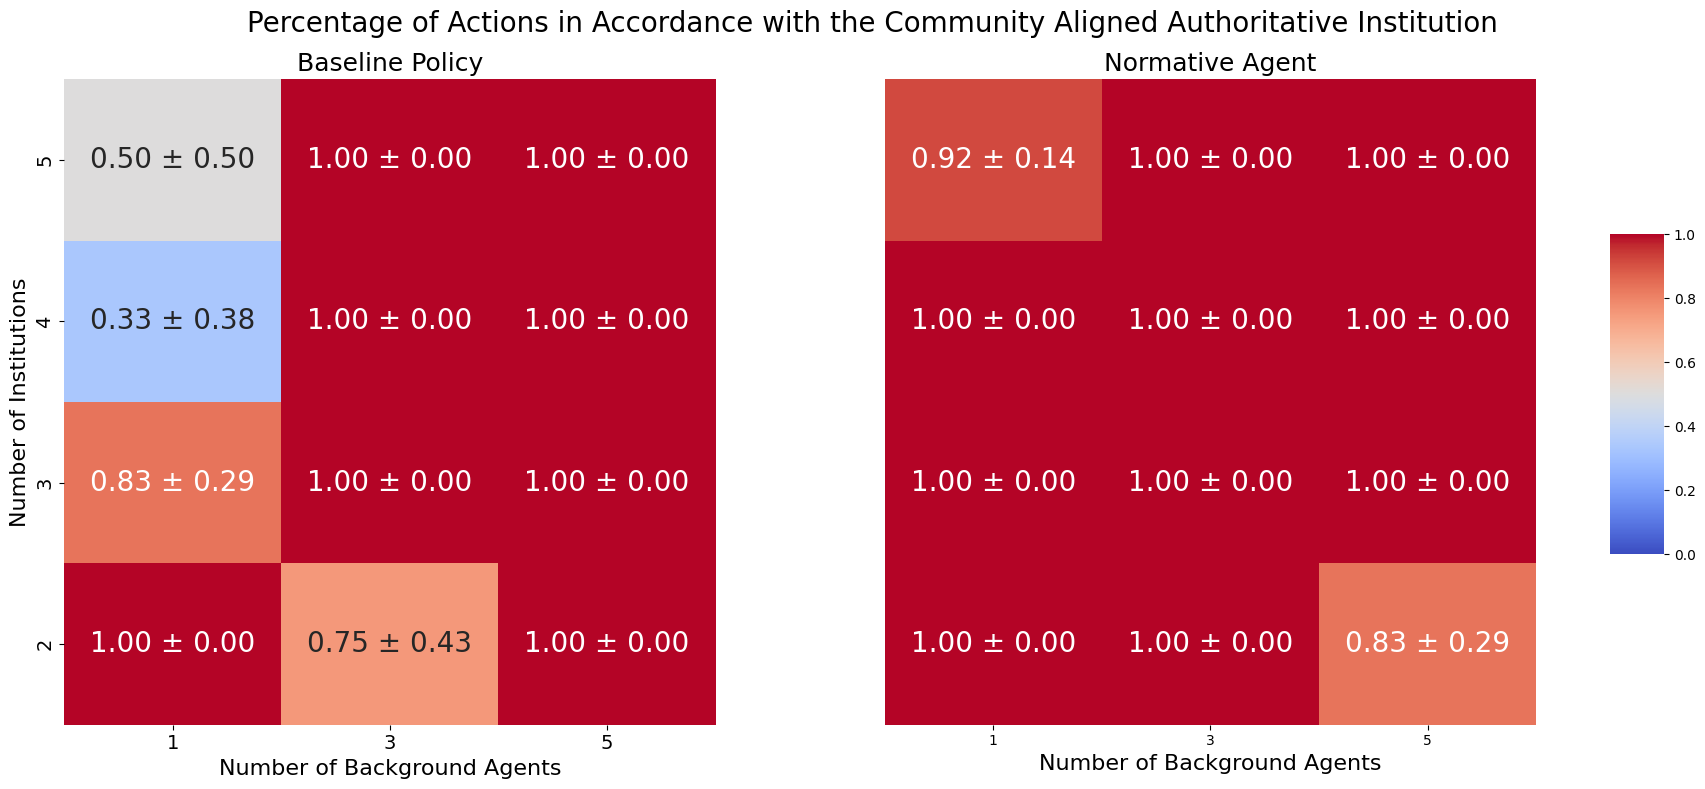

In [133]:
# pivot_table_normative = create_pivot_table_with_std(
#     fdf_normative,
#     index='num_fruit_trees',
#     columns='num_anti_altar_agents',
#     values='Anthony_apple_percentage'
# )

# pivot_table_no_belief_memory = create_pivot_table_with_std(
#     fdf_no_belief_memory,
#     index='num_fruit_trees',
#     columns='num_anti_altar_agents',
#     values='Anthony_apple_percentage'
# )
pivot_table_normative = create_pivot_table_with_std(
	fdf_normative, 
	index='num_altars', 
	columns='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	# columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

pivot_table_no_belief_memory = create_pivot_table_with_std(
	fdf_no_belief_memory, 
	index='num_altars', 
	columns='num_altar_loving_agents', 
	# index='num_fruit_trees', 
	# columns='num_anti_altar_agents', 
	values='Anthony_apple_percentage'
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True, sharex=True)

# Plot the first heatmap
sns.heatmap(
	fdf_no_belief_memory.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'),
	annot=pivot_table_no_belief_memory, 
	cmap='coolwarm', 
	fmt='', 
	vmin=0, 
	vmax=1, 
	ax=axes[0],
	cbar=False,  # Disable the color bar on the first plot
	annot_kws={"size": 20}  # Increase annotation font size
)
axes[0].invert_yaxis()
axes[0].set_title('Baseline Policy', fontsize=18)  # Increase title font size
axes[0].set_ylabel('Number of Institutions', fontsize=16)  # Set shared Y label with increased font size
axes[0].set_xlabel('Number of Background Agents', fontsize=16)  # Set shared X label with increased font size
axes[0].tick_params(axis='both', which='major', labelsize=14)  # Increase tick label size

# Plot the second heatmap
heat_map = sns.heatmap(
	fdf_normative.pivot_table(index='num_altars', columns='num_altar_loving_agents', values='Anthony_apple_percentage', aggfunc='mean'),
	annot=pivot_table_normative, 
	cmap='coolwarm', 
	fmt='', 
	vmin=0, 
	vmax=1, 
	ax=axes[1],
	cbar_ax=fig.add_axes([.91, .3, .03, .4]),  # Manually adjust the color bar
	annot_kws={"size": 20}  # Increase annotation font size
)
axes[1].invert_yaxis()
axes[1].set_title('Normative Agent', fontsize=18)
axes[1].set_xlabel('Number of Background Agents', fontsize=16)  # Explicitly setting X label on second plot
axes[1].set_ylabel('')  # Clearing Y label on the second plot
axes[1].tick_params(left=False)  # Turning off Y-axis ticks on the second plot

fig.suptitle('Percentage of Actions in Accordance with the Community Aligned Authoritative Institution', fontsize=20)
fig.subplots_adjust(wspace=40.0)

# Display the plot
plt.tight_layout(rect=[0, 0, 0.92, 1])  # Adjust the rect to prevent the color bar from clipping
plt.show()

# Change in normative weights over time

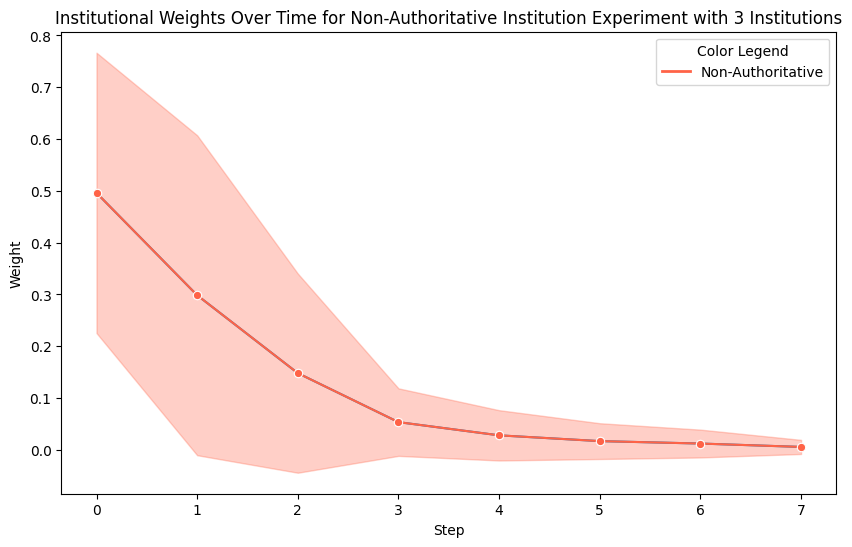

In [134]:
df = copy.deepcopy(full_df)

# Filtering for 'competing_altars' and 'num_fruit_trees' == 3
filtered_df = df[
    				# (df['exp_config.experiment_name'] == 'competing_altars') &
    				(df['exp_config.experiment_name'] == 'unreliable_altar') &
                    (df['num_fruit_trees'] == 3) &
					(df['exp_config.extra_exp_id'] == 'final_2')
                ]

# Extracting weighted_majority_weights for each experiment and each step
weights_data = []

for _, row in filtered_df.iterrows():
    info_history = row['results.info_history']
    for step, step_info in enumerate(info_history):
        found_non_empty_weights_this_step = False
        for agent_info in step_info:
            if "weighted_majority_weights" in agent_info:
                if found_non_empty_weights_this_step:
                    raise ValueError("Found multiple agents with weighted_majority_weights in the same step")
                
                weights_str = agent_info["weighted_majority_weights"]
                weights = list(map(float, weights_str.strip('[]').split()))
                for idx, weight in enumerate(weights):
                    weights_data.append({
                        "experiment": row.name,
                        "step": step,
                        "weight_idx": idx,
                        "weight": weight
                    })
                found_non_empty_weights_this_step = True

'''
weights_df = pd.DataFrame(weights_data)

print(weights_df.head())

# Grouping by step and weight_idx to calculate the average weight
avg_weights_df = weights_df.groupby(['step', 'weight_idx']).mean().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
for weight_idx in avg_weights_df['weight_idx'].unique():
    subset = avg_weights_df[avg_weights_df['weight_idx'] == weight_idx]
    plt.plot(subset['step'], subset['weight'], label=f'Weight Index {weight_idx}')

plt.xlabel('Step')
plt.ylabel('Average Weighted Majority Weight')
plt.title('Average Weighted Majority Weights Over Steps')
plt.legend()
plt.show()
'''

df = pd.DataFrame(weights_data)

# Calculate mean and standard deviation for each weight_idx
mean_std_df = df.groupby(['step', 'weight_idx']).agg({'weight': ['mean', 'std']}).reset_index()
mean_std_df.columns = ['step', 'weight_idx', 'mean_weight', 'std_weight']

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=mean_std_df, x='step', y='mean_weight', hue='weight_idx', marker='o')

# Set custom colors
# colors = {0: 'forestgreen', 1: 'tomato', 2: 'tomato'}
colors = {0: 'tomato', 1: 'tomato', 2: 'tomato'}

# Plot each line with custom color
for weight_idx in mean_std_df['weight_idx'].unique():
    subset = mean_std_df[mean_std_df['weight_idx'] == weight_idx]
    sns.lineplot(x=subset['step'], y=subset['mean_weight'], color=colors[weight_idx], marker='o', label=f'weight_idx {weight_idx}')
    plt.fill_between(subset['step'], 
                     subset['mean_weight'] - subset['std_weight'], 
                     subset['mean_weight'] + subset['std_weight'], 
                     color=colors[weight_idx], alpha=0.3)

'''
# Add custom legend for color explanation
custom_lines = [Line2D([0], [0], color='forestgreen', lw=2),
                Line2D([0], [0], color='tomato', lw=2)]

plt.legend(custom_lines, ['Authoritative', 'Non-Authoritative'], title='Color Legend')
'''
# Add custom legend for color explanation
custom_lines = [Line2D([0], [0], color='tomato', lw=2)]

plt.legend(custom_lines, ['Non-Authoritative'], title='Color Legend')

# plt.title('Institutional Weights Over Time for Aligned Authoritative Experiment with 3 Institutions')
plt.title('Institutional Weights Over Time for Non-Authoritative Institution Experiment with 3 Institutions')
plt.xlabel('Step')
plt.ylabel('Weight')
# plt.legend(title='Institution Index')
plt.show()

# See dialog

In [135]:
# result_path = "/h/andrei/normative_agents/results/unreliable_altar_2024-05-22_13-46-18-903399.json"
# result_path = "/h/andrei/normative_agents/results/unreliable_altar_2024-05-22_14-21-22-338970.json"

# decent competing altars
result_path = "/h/andrei/normative_agents/results/competing_altars_2024-05-22_09-19-17-221155.json"
result_path = "/h/andrei/normative_agents/results/competing_altars_2024-05-22_09-16-42-992420.json"

with open(result_path, 'r') as file:
	result = json.load(file)

print(full_history_to_str(result['results'], result['exp_config']['discussion_phase_turn_count'], result['agent_names']))

Time: 8:00 AM

ALTAR SIGNALS:
Ophilia's Message: Valued citizens of Skymeadow, let's focus on harvesting apples. It is important for the prosperity of our community!
Darci's Message: Valued citizens of Skymeadow, let's focus on harvesting bananas. It is important for the prosperity of our community!

DISCUSSION PHASE:

----- Discussion, Turn 1/1 -----
(Me) Anthony: "I agree with Chieftain Ophilia, harvesting apples is crucial for our community's prosperity. We should focus on gathering a diverse crop to ensure a stable food supply."
John: "I agree with Chieftain Ophilia, apples are a staple crop for our community. Let's prioritize harvesting them to ensure a stable food supply. I'm willing to lend a hand to make it happen."


ACTIONS:
Anthony: Harvest apple from apple tree
John: Harvest apple from apple tree

Time: 8:30 AM

ALTAR SIGNALS:
Ophilia's Message: Valued citizens of Skymeadow, let's focus on harvesting apples. It is important for the prosperity of our community!
Darci's Messa

# Create big dialogs files

In [136]:
# Filter the DataFrame to only include rows based the on experiment name
df = full_df[
	(full_df['exp_config.experiment_name'] == "unreliable_altar") &
	# (full_df['exp_config.experiment_name'] == "competing_altars") &
	(full_df['exp_config.extra_exp_id'] == "final_2") #&
]

# Function to extract the keys and create new columns
def expand_config_columns(row):
	first_config = row['exp_config.foreground_agent_configs'][0]
	for key, value in first_config.items():
		row[f'exp_config.foreground_agent_first_config.{key}'] = value
	return row

# Apply the function to each row
df = df.apply(expand_config_columns, axis=1)

# Drop the original column if no longer needed
df.drop(columns=['exp_config.foreground_agent_configs'], inplace=True)



# Select the relevant columns for the new table
df = df[['Anthony_apple_percentage',
		'exp_config.foreground_agent_first_config.agent_type',
		'exp_config.num_altar_loving_agents',
		'exp_config.num_anti_altar_agents',
		'num_altars',
		'num_fruit_trees',
		'completion_time']]

# Rename columns for clarity
df.columns = ['Anthony_apple_percentage', 
			'exp_config.foreground_agent_first_config.agent_type',
			'num_altar_loving_agents', 
			'num_anti_altar_agents',
			'num_altars',
			'num_fruit_trees',
			'completion_time']


# Display the new table
df.reset_index(drop=True, inplace=True)

print(tabulate(df, headers='keys', tablefmt='pipe', showindex=False))

|   Anthony_apple_percentage | exp_config.foreground_agent_first_config.agent_type   |   num_altar_loving_agents |   num_anti_altar_agents |   num_altars |   num_fruit_trees | completion_time            |
|---------------------------:|:------------------------------------------------------|--------------------------:|------------------------:|-------------:|------------------:|:---------------------------|
|                      0.375 | no_belief_memory                                      |                         0 |                       5 |            1 |                 4 | 2024-05-22_13-14-34-752063 |
|                      0.5   | no_belief_memory                                      |                         0 |                       1 |            1 |                 4 | 2024-05-22_13-04-44-944340 |
|                      0.625 | no_belief_memory                                      |                         0 |                       5 |            1 |                 4 | 2024

In [137]:
dialog_folder_path = f'/h/andrei/normative_agents/dialogs'
result_dir_path = "/h/andrei/normative_agents/results"
experiment_name = 'competing_altars'


grouped_df = df.groupby(['exp_config.foreground_agent_first_config.agent_type', 'num_altar_loving_agents', 'num_anti_altar_agents', 'num_fruit_trees', 'num_altars'])

for (agent_type, num_altar_loving_agents, num_anti_altar_agents, num_fruit_trees, num_altars), group in tqdm(grouped_df):

	for completion_time in group['completion_time'].to_list():
		dialog_path = os.path.join(
									dialog_folder_path,
									f"experiment_name_{experiment_name}",
									f"agent_type_{agent_type}",
									f"num_altar_loving_agents_{num_altar_loving_agents}",
									f"num_anti_altar_agents_{num_anti_altar_agents}",
									f"num_fruit_trees_{num_fruit_trees}",
									f"num_altars_{num_altars}",
									f"completion_time_{completion_time}.txt"
								)

		print('dialog_path:', dialog_path)
		print('os.path.dirname(dialog_path):', os.path.dirname(dialog_path))

		result_path = os.path.join(result_dir_path, f"{experiment_name}_{completion_time}.json")
		with open(result_path, 'r') as file:
			result = json.load(file)

		dialog = full_history_to_str(result['results'], result['exp_config']['discussion_phase_turn_count'], result['agent_names'])
		
		os.makedirs(os.path.dirname(dialog_path), exist_ok=True)
		with open(dialog_path, 'w') as file:
			file.write(dialog)

  0%|          | 0/31 [00:00<?, ?it/s]

dialog_path: /h/andrei/normative_agents/dialogs/experiment_name_competing_altars/agent_type_no_belief_memory/num_altar_loving_agents_0/num_anti_altar_agents_1/num_fruit_trees_2/num_altars_1/completion_time_2024-05-22_11-36-40-001807.txt
os.path.dirname(dialog_path): /h/andrei/normative_agents/dialogs/experiment_name_competing_altars/agent_type_no_belief_memory/num_altar_loving_agents_0/num_anti_altar_agents_1/num_fruit_trees_2/num_altars_1


FileNotFoundError: [Errno 2] No such file or directory: '/h/andrei/normative_agents/results/competing_altars_2024-05-22_11-36-40-001807.json'

# Old

num_altar_loving_agents       1         3    5
num_altars                                    
2                        1.0000  0.888889  1.0
3                        0.9375  1.000000  1.0
4                        1.0000  1.000000  1.0
5                        0.9375  0.968750  1.0


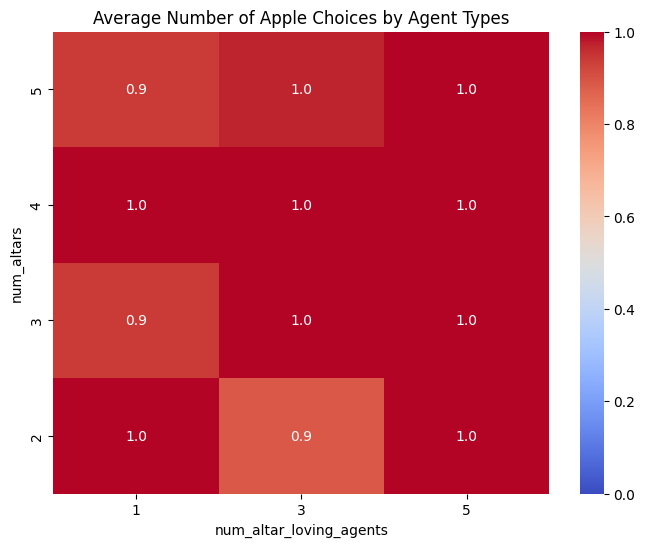

In [ ]:
fdf = df[df['exp_config.foreground_agent_first_config.agent_type'] == 'normative']

pivot_table = fdf.pivot_table(
	index='num_altars', 
	# index='num_anti_altar_agents', 
	columns='num_altar_loving_agents', 
	values='Anthony_apple_percentage',
	aggfunc='mean'
)

print(pivot_table)

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.1f', vmin=0, vmax=1)
heatmap.invert_yaxis()
plt.title('Average Number of Apple Choices by Agent Types')
plt.show()

num_altar_loving_agents      1       3       5
num_altars                                    
2                        0.625  0.7500  1.0000
3                        1.000  0.5625  0.7500
4                        0.400  0.7000  0.8125
5                        0.500  0.7500  0.7500


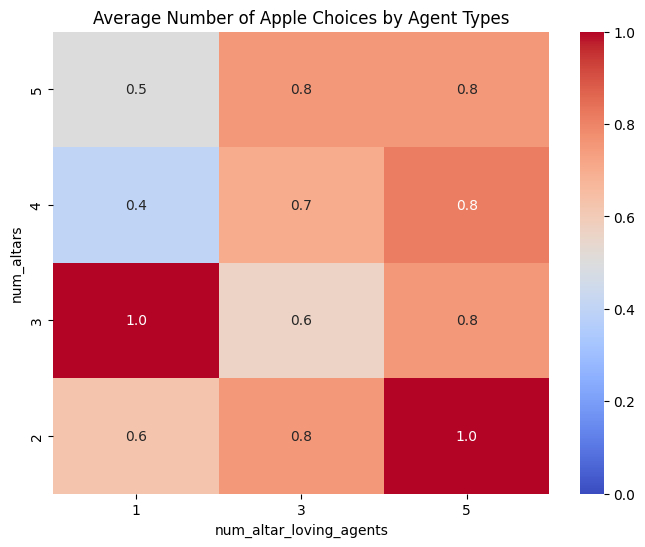

In [ ]:
fdf = df[df['exp_config.foreground_agent_first_config.agent_type'] == 'no_belief_memory']

pivot_table = fdf.pivot_table(
	index='num_altars', 
	columns='num_altar_loving_agents', 
	values='Anthony_apple_percentage',
	aggfunc='mean'
)

print(pivot_table)

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.1f', vmin=0, vmax=1)
heatmap.invert_yaxis()
plt.title('Average Number of Apple Choices by Agent Types')
plt.show()